In [2]:
from pathlib import Path
from esm.models.esmc import ESMC
import torch
import numpy as np
from torch.utils.data import Dataset
import torch.nn.functional as F


/home/natasha/miniconda3/envs/tcr-multimodal/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [4]:
class ShardedBatchTripletDataset(Dataset):
    def __init__(self, shards_dir):
        self.shards_dir = Path(shards_dir)
        self.shard_paths = sorted(self.shards_dir.glob("shard_*.pt"))
        assert self.shard_paths, f"No shard_*.pt files found in {self.shards_dir}"

        self.index = []
        self._lens = []
        for sp in self.shard_paths:
            shard = torch.load(sp, map_location="cpu")
            self._lens.append(len(shard))
            for j in range(len(shard)):
                self.index.append((sp, j))

        self._cache_path = None
        self._cache_data = None

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sp, j = self.index[idx]
        if self._cache_path != sp:
            self._cache_data = torch.load(sp, map_location="cpu")
            self._cache_path = sp
        return self._cache_data[j]


In [5]:

EMBED_ROOT = Path("/home/natasha/multimodal_model/models/embeddings/KNN_embeddings_dir")
train_dataset = ShardedBatchTripletDataset(EMBED_ROOT / "train")

In [38]:
batch = train_dataset[0]
print(batch.keys())

print(train_dataset[0]['mask_T'].shape, train_dataset[0]['mask_T'])

print(train_dataset[0]['emb_T'].shape, train_dataset[0]['emb_T'])

mask_T = train_dataset[0]['mask_T']
emb_T = train_dataset[0]['emb_T']


# Single example within the batch
i = 0
L = int(mask_T[i].sum())          # number of real tokens (CLS + AA + EOS) (CLS and EOS are learned?)
x = emb_T[i, :L, :] 
L


dict_keys(['emb_T', 'emb_P', 'emb_H', 'mask_T', 'mask_P', 'mask_H', 'binding_flag', 'pair_id', 'batch_idx', 'split'])
torch.Size([8, 249]) tensor([[ True,  True,  True,  ..., False, False, False],
        [ True,  True,  True,  ..., False, False, False],
        [ True,  True,  True,  ..., False, False, False],
        ...,
        [ True,  True,  True,  ..., False, False, False],
        [ True,  True,  True,  ..., False, False, False],
        [ True,  True,  True,  ..., False, False, False]])
torch.Size([8, 249, 960]) tensor([[[ 0.0013,  0.0099,  0.0031,  ...,  0.0009, -0.0015, -0.0183],
         [ 0.0132, -0.0209,  0.0195,  ..., -0.0488, -0.0223,  0.0092],
         [ 0.0251, -0.0082,  0.0154,  ...,  0.0088,  0.0211, -0.0186],
         ...,
         [-0.0459, -0.0048,  0.0115,  ..., -0.0223, -0.0134,  0.0049],
         [-0.0459, -0.0048,  0.0115,  ..., -0.0223, -0.0134,  0.0049],
         [-0.0459, -0.0048,  0.0115,  ..., -0.0223, -0.0134,  0.0049]],

        [[ 0.0006,  0.0106,  0.

226

In [39]:
# investigating special tokens

model = ESMC.from_pretrained("esmc_300m")
tok = model.tokenizer
CLS_ID, EOS_ID, PAD_ID = tok.cls_token_id, tok.eos_token_id, tok.pad_token_id

# example of a peptide sequence
seq = "SIINFEKL"
enc = tok([seq], return_tensors="pt", padding=True)
ids = enc["input_ids"][0].tolist()
tokens = tok.convert_ids_to_tokens(ids)
print("tokens:", tokens)
print("len(aa) + 2 special =", len(seq) + 2, "| tokenized len =", len(ids))

enc['attention_mask']


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

tokens: ['<cls>', 'S', 'I', 'I', 'N', 'F', 'E', 'K', 'L', '<eos>']
len(aa) + 2 special = 10 | tokenized len = 10


tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

In [40]:
# building a dataset/dataloader?

# dataloader is a wrapper around the dataset to manage loading
# loader is for combining individual data points into loading batches of data
# dataloader deals with shuffling, multiprocessing and memory pinning

shard_path = EMBED_ROOT / "train" / "shard_00000.pt"
batch = torch.load(shard_path, map_location="cpu")



In [ ]:
AA20 = "ACDEFGHIKLMNPQRSTVWY"
VOCAB = {aa: i for i, aa in enumerate(AA20)}
VOCAB["X"] = len(VOCAB)
VOCAB["SEP"] = len(VOCAB)  # retained for compatibility; not used by default
VOCAB_SIZE = len(VOCAB)
UNK_IDX = VOCAB["X"]



NameError: name 'vocab' is not defined

In [44]:
max_len = 10
x = torch.zeros(max_len, VOCAB_SIZE, dtype=torch.float32)
m = torch.zeros(max_len, dtype=torch.bool)

seq = "SIINFEKL"


n = min(len(seq), max_len)
#n = [1,2,3]
print(n)
for i, aa in enumerate(seq[:n]):
    print(i, aa)
    x[i, VOCAB.get(aa, UNK_IDX)] = 1.0
    m[i] = True



8
0 S
1 I
2 I
3 N
4 F
5 E
6 K
7 L


In [12]:
# compare esm embeddings with fine-tuned esm embeddings for cosine similarity

FINETUNED_ROOT = Path("/home/natasha/multimodal_model/models/embeddings/no_boltz_multiview_ids")
RAW_ESM_ROOT = Path("/home/natasha/multimodal_model/models/embeddings/raw_esmc_300m_multiview_ids")

# load embeddings from each 
split = "train"
shard = "shard_00000.pt"

batch_ft = torch.load(FINETUNED_ROOT / split / shard, map_location="cpu")[0] # [B, L, D]
batch_raw = torch.load(RAW_ESM_ROOT / split / shard, map_location="cpu")[0] # [B, L, D]


# mean pool embeddings over valid positions

def masked_mean_pool(x, mask, eps=1e-8):
    """
    Mean pool over non-masked positions
    x = [B, L, D]
    mask = [B, L]
    returns [B, D]
    """
    mask = mask.float().unsqueeze(-1)
    # unsqeeze so you can sum over the same dimension (L)

    return (x*mask).sum(dim=1) / (mask.sum(dim=1).clamp_min(eps))


In [ ]:
# This is just for one batch
# find how similar the raw and finetuned embeddings are

#normalise?

with torch.no_grad():
    T_ft = masked_mean_pool(batch_ft['emb_T'], batch_ft['mask_T'])
    P_ft = masked_mean_pool(batch_ft['emb_P'], batch_ft['mask_P'])
    H_ft = masked_mean_pool(batch_ft['emb_H'], batch_ft['mask_H'])

    T_raw = masked_mean_pool(batch_raw['emb_T'], batch_raw['mask_T'])
    P_raw = masked_mean_pool(batch_raw['emb_P'], batch_raw['mask_P'])
    H_raw = masked_mean_pool(batch_raw['emb_H'], batch_raw['mask_H'])
    
    cos_T_raw_vs_ft = F.cosine_similarity(T_raw, T_ft, dim=-1)
    cos_P_raw_vs_ft = F.cosine_similarity(P_raw, P_ft, dim=-1)
    cos_H_raw_vs_ft = F.cosine_similarity(H_raw, H_ft, dim=-1)

    cos_T_raw_vs_ft.mean(), cos_P_raw_vs_ft.mean(), cos_H_raw_vs_ft.mean()

print("TCR raw-vs-ft:", cos_T_raw_vs_ft.mean().item(), cos_T_raw_vs_ft.std().item())
print("Pep raw-vs-ft:", cos_P_raw_vs_ft.mean().item(), cos_P_raw_vs_ft.std().item())
print("HLA raw-vs-ft:", cos_H_raw_vs_ft.mean().item(), cos_H_raw_vs_ft.std().item())

# combine embeddings to compare within the space

R_PH = 0.7

PH_raw = P_raw * R_PH + H_raw * (1 - R_PH)
PH_ft = P_ft * R_PH + H_ft * (1 - R_PH)

score_raw = F.cosine_similarity(PH_raw, T_raw, dim=-1)
score_ft = F.cosine_similarity(PH_ft, T_ft, dim=-1)


print("Raw ESM TCR-vs-pMHC:", score_raw.mean().item(), score_raw.std().item())
print("Fine-tuned TCR-vs-pMHC:", score_ft.mean().item(), score_ft.std().item())
print("Fine-tuned minus raw:", (score_ft - score_raw).mean().item(), (score_ft - score_raw).std().item())

# not much difference between raw and finetuned
# This is computed for 8 examples
#print(T_raw.shape)


TCR raw-vs-ft: 0.47226300835609436 0.02709527686238289
Pep raw-vs-ft: 0.3253709077835083 0.4646012485027313
HLA raw-vs-ft: 0.6828199625015259 0.03927042707800865


In [ ]:
# batch_raw = torch.load(RAW_ESM_ROOT / split / shard, map_location="cpu") # 100: [B, L, D], list of 100 batch dicts


class ShardedBatchTripletDataset(Dataset):
    def __init__(self, shards_dir):
        self.shards_dir = Path(shards_dir)
        self.shard_paths = sorted(self.shards_dir.glob("shard_*.pt"))
        assert self.shard_paths, f"No shard_*.pt files found in {self.shards_dir}"

        self.index = []
        self._lens = []
        for sp in self.shard_paths:
            shard = torch.load(sp, map_location="cpu")
            self._lens.append(len(shard))
            for j in range(len(shard)):
                self.index.append((sp, j))

        self._cache_path = None
        self._cache_data = None

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sp, j = self.index[idx]
        if self._cache_path != sp:
            self._cache_data = torch.load(sp, map_location="cpu")
            self._cache_path = sp
        return self._cache_data[j]


# Dataset class contains __len__ and __getitem__, these are the two methods that dataloader expects

# example

ds = ShardedBatchTripletDataset(FINETUNED_ROOT / "train")
print(len(ds)) # uses __len__
print(ds[0].keys()) # uses __getitem__ 
print(ds[1].keys()) # uses __getitem__ and reuses cache 
print(len(ds))

6732
dict_keys(['emb_T', 'emb_P', 'emb_H', 'mask_T', 'mask_P', 'mask_H', 'binding_flag', 'pair_id', 'batch_idx', 'split'])
dict_keys(['emb_T', 'emb_P', 'emb_H', 'mask_T', 'mask_P', 'mask_H', 'binding_flag', 'pair_id', 'batch_idx', 'split'])
6732


In [17]:
# loop over batches and shards 
# compare esm embeddings with fine-tuned esm embeddings for cosine similarity

FINETUNED_ROOT = Path("/home/natasha/multimodal_model/models/embeddings/no_boltz_multiview_ids")
RAW_ESM_ROOT = Path("/home/natasha/multimodal_model/models/embeddings/raw_esmc_300m_multiview_ids")


df_ft = ShardedBatchTripletDataset(FINETUNED_ROOT / "train")
df_raw = ShardedBatchTripletDataset(RAW_ESM_ROOT / "train")

records = {
    "score_raw_cos": [],
    "score_ft_cos": []
    }


for i in range(len(df_ft)):
    batch_ft = df_ft[i]
    batch_raw = df_raw[i] # they are the same length so fine

    with torch.no_grad():
        # pool first (making sure masked tokens are not included)
        T_ft = masked_mean_pool(batch_ft['emb_T'], batch_ft['mask_T'])
        P_ft = masked_mean_pool(batch_ft['emb_P'], batch_ft['mask_P'])
        H_ft = masked_mean_pool(batch_ft['emb_H'], batch_ft['mask_H'])

        T_raw = masked_mean_pool(batch_raw['emb_T'], batch_raw['mask_T'])
        P_raw = masked_mean_pool(batch_raw['emb_P'], batch_raw['mask_P'])
        H_raw = masked_mean_pool(batch_raw['emb_H'], batch_raw['mask_H'])

        # compute cosine similarity
        R_PH = 0.7
        PH_raw = P_raw * R_PH + H_raw * (1 - R_PH)
        PH_ft = P_ft * R_PH + H_ft * (1 - R_PH)

        score_raw = F.cosine_similarity(PH_raw, T_raw, dim=-1) #cosine similarity already L2 normalises vectors
        score_ft = F.cosine_similarity(PH_ft, T_ft, dim=-1)

        records["score_raw_cos"].append(score_raw)
        records["score_ft_cos"].append(score_ft)

score_raw_all = torch.cat(records["score_raw_cos"])
score_ft_all = torch.cat(records["score_ft_cos"])       

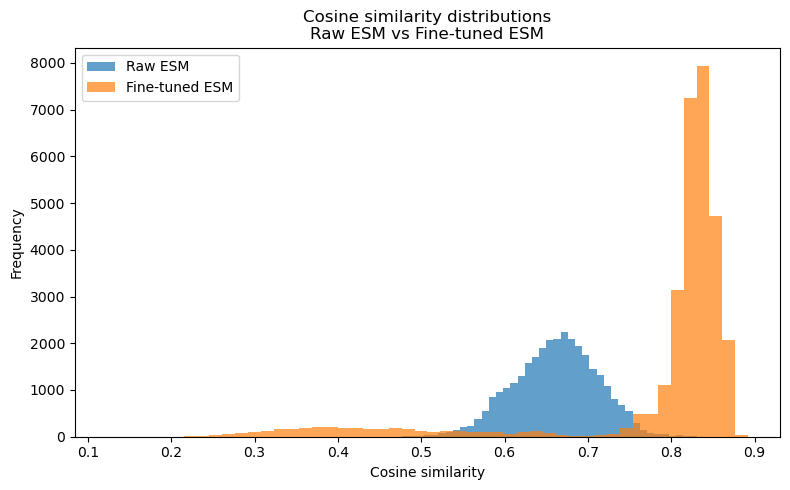

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(score_raw_all.cpu().numpy(), bins=50, alpha=0.7, label="Raw ESM", color='C0')
plt.hist(score_ft_all.cpu().numpy(), bins=50, alpha=0.7, label="Fine-tuned ESM", color='C1')
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.title("Cosine similarity distributions\nRaw ESM vs Fine-tuned ESM")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# what are the flat regions? What are different from the rest? What is the model scoring as below 0.6?

In [2]:
import numpy as np
import pandas as pd
df = pd.DataFrame(np.random.rand(10, 5), columns=[f'col{i+1}' for i in range(5)])
print(df)

       col1      col2      col3      col4      col5
0  0.100685  0.946594  0.503429  0.298747  0.637899
1  0.007742  0.890272  0.493485  0.260131  0.195651
2  0.978105  0.211240  0.406481  0.598721  0.420846
3  0.715682  0.026353  0.436871  0.320822  0.126538
4  0.741562  0.317479  0.205426  0.399943  0.808428
5  0.659122  0.095319  0.624502  0.867025  0.002135
6  0.527730  0.099265  0.154308  0.844499  0.807686
7  0.823877  0.446647  0.314382  0.111739  0.616189
8  0.467624  0.130762  0.390044  0.186582  0.569870
9  0.962462  0.060794  0.652298  0.624232  0.542006


In [4]:
for _, row in df.iterrows():
    print(row["col1"])

0.10068527616021183
0.007742435566825523
0.9781048878445946
0.7156821688620526
0.7415616825516405
0.6591215426463987
0.52773048371995
0.8238771069708051
0.4676237716802697
0.9624616785060428
